# TITAN-FND v3 — GossipCop (Title Only)
**Key fixes over v2:**
- Removed WeightedRandomSampler (was conflicting with weighted loss)
- Focal loss instead of weighted CE (handles imbalance + hard examples)
- Frozen ALL encoder layers except top 3 (prevents memorisation)
- LR reduced across the board
- Orthogonal loss to force attention head specialisation
- Increased label smoothing to 0.1
- Checkpoint on F1, early stopping patience=2

## 1. Install

In [4]:
%%capture
!pip install transformers==4.40.0 accelerate sentencepiece protobuf -q

## 2. Imports & seeds

In [5]:
    import os, re, random, warnings
    import numpy as np
    import pandas as pd
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns
    warnings.filterwarnings('ignore')

    SEED = 42
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device : {DEVICE}')
    if torch.cuda.is_available():
        print(f'GPU    : {torch.cuda.get_device_name(0)}')

Device : cuda
GPU    : Tesla T4


## 3. Load & prepare data

In [6]:
REAL_PATH = '/kaggle/input/datasets/akshaynarayananb/gossipcop/gossipcop_real.csv'
FAKE_PATH = '/kaggle/input/datasets/akshaynarayananb/gossipcop/gossipcop_fake.csv'

df_real = pd.read_csv(REAL_PATH, usecols=['title'])
df_fake = pd.read_csv(FAKE_PATH, usecols=['title'])
df_real['label'] = 0
df_fake['label'] = 1

df = pd.concat([df_real, df_fake], ignore_index=True)

def clean_title(text):
    if not isinstance(text, str): return ''
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    return text

df['title'] = df['title'].apply(clean_title)
df = df[df['title'].str.len() > 5].reset_index(drop=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Total  : {len(df)}')
print(f'Real   : {(df.label==0).sum()}')
print(f'Fake   : {(df.label==1).sum()}')
print(f'Ratio  : {(df.label==0).sum()/(df.label==1).sum():.2f}:1')

Total  : 22140
Real   : 16817
Fake   : 5323
Ratio  : 3.16:1


## 4. Split

In [7]:
X = df['title'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Train : {len(X_train)}  Real={np.sum(y_train==0)}  Fake={np.sum(y_train==1)}')
print(f'Val   : {len(X_val)}   Real={np.sum(y_val==0)}  Fake={np.sum(y_val==1)}')
print(f'Test  : {len(X_test)}   Real={np.sum(y_test==0)}  Fake={np.sum(y_test==1)}')

Train : 17712  Real=13454  Fake=4258
Val   : 2214   Real=1681  Fake=533
Test  : 2214   Real=1682  Fake=532


## 5. Tokenizer & Dataset

In [8]:
MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN    = 64
BATCH_SIZE = 16   # reduced from 32 — smaller batches = better gradient estimates

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TitleDataset(Dataset):
    def __init__(self, titles, labels, tokenizer, max_len):
        self.titles = titles; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len

    def __len__(self): return len(self.titles)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.titles[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'token_type_ids' : enc.get(
                'token_type_ids',
                torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = TitleDataset(X_train, y_train, tokenizer, MAX_LEN)
val_ds   = TitleDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_ds  = TitleDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# No sampler — focal loss handles imbalance directly
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_dl)} | val: {len(val_dl)} | test: {len(test_dl)}')

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Batches — train: 1107 | val: 139 | test: 139


## 6. Focal Loss
Focal loss does two things simultaneously:
- Down-weights easy examples (model already confident) so hard examples dominate training
- The alpha parameter handles class imbalance (higher alpha = more weight on Fake class)

This replaces both WeightedRandomSampler AND weighted CE — one clean solution.

In [9]:
class FocalLoss(nn.Module):
    """
    FL(p) = -alpha * (1 - p)^gamma * log(p)
    gamma : focusing parameter — higher = more focus on hard/misclassified examples
    alpha : per-class weight — set higher for minority (Fake) class
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha     = alpha      # tensor of shape (num_classes,)
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')  # (B,)
        pt      = torch.exp(-ce_loss)                                 # prob of correct class
        focal   = (1 - pt) ** self.gamma * ce_loss                    # down-weight easy

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal   = alpha_t * focal

        return focal.mean() if self.reduction == 'mean' else focal.sum()


# Compute alpha from class frequencies
class_counts = np.bincount(y_train)          # [n_real, n_fake]
total        = class_counts.sum()
# Inverse frequency, normalised — Fake gets higher alpha
alpha_vals   = torch.tensor(
    [total / (2 * class_counts[0]),
     total / (2 * class_counts[1])],
    dtype=torch.float
).to(DEVICE)

criterion = FocalLoss(alpha=alpha_vals, gamma=2.0)

print(f'Alpha — Real: {alpha_vals[0]:.4f}  Fake: {alpha_vals[1]:.4f}')
print('Fake class gets {:.1f}x more weight than Real'.format(
    alpha_vals[1].item() / alpha_vals[0].item()))

Alpha — Real: 0.6582  Fake: 2.0798
Fake class gets 3.2x more weight than Real


## 7. TITAN-FND Model v3
Key changes:
- Separate projection per attention head (forces specialisation)
- Orthogonal loss support (sem/emo/syn vectors returned)
- Dropout raised to 0.5
- Only top 3 encoder layers unfrozen

In [10]:
class TripleStreamAttention(nn.Module):
    """
    Each head projects to its own subspace before attending.
    This structural separation forces each head to learn
    different features rather than collapsing to the same solution.
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        d = hidden_size // 2   # projected dimension per head

        # Each head: project → attend → pool
        self.sem_proj = nn.Linear(hidden_size, d)
        self.emo_proj = nn.Linear(hidden_size, d)
        self.syn_proj = nn.Linear(hidden_size, d)

        self.sem_attn = nn.Linear(d, 1)
        self.emo_attn = nn.Linear(d, 1)
        self.syn_attn = nn.Linear(d, 1)

        self.d = d

    def _attend(self, proj, attn, hidden, mask):
        h = torch.tanh(proj(hidden))              # (B, T, d)
        scores  = attn(h).squeeze(-1)             # (B, T)
        scores  = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=-1)   # (B, T)
        return (weights.unsqueeze(-1) * h).sum(dim=1)  # (B, d)

    def forward(self, hidden, mask):
        sem = self._attend(self.sem_proj, self.sem_attn, hidden, mask)
        emo = self._attend(self.emo_proj, self.emo_attn, hidden, mask)
        syn = self._attend(self.syn_proj, self.syn_attn, hidden, mask)
        return sem, emo, syn   # each (B, d)


class GatedFusion(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.gate = nn.Linear(d * 3, 3)

    def forward(self, sem, emo, syn):
        concat = torch.cat([sem, emo, syn], dim=-1)   # (B, 3d)
        gates  = torch.sigmoid(self.gate(concat))     # (B, 3)
        g_s, g_e, g_n = gates[:, 0:1], gates[:, 1:2], gates[:, 2:3]
        fused = g_s * sem + g_e * emo + g_n * syn     # (B, d)
        return fused, gates


class TITANFND(nn.Module):
    def __init__(self, model_name: str, num_labels: int = 2, dropout: float = 0.5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        H = self.encoder.config.hidden_size   # 768
        d = H // 2                            # 384 — per-head projected dim

        self.triple_attn  = TripleStreamAttention(H)
        self.gated_fusion = GatedFusion(d)

        # CLS projection (also to d for consistent sizing)
        self.cls_proj = nn.Sequential(
            nn.Linear(H, d),
            nn.Tanh()
        )

        # Classifier input: fused (d) + cls (d) = 2d
        self.classifier = nn.Sequential(
            nn.Linear(d * 2, d),
            nn.LayerNorm(d),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d, d // 2),
            nn.LayerNorm(d // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d // 2, num_labels)
        )
        self._init_weights()

    def _init_weights(self):
        for module in [self.triple_attn, self.gated_fusion,
                       self.cls_proj, self.classifier]:
            for p in module.parameters():
                if p.dim() > 1:
                    nn.init.xavier_uniform_(p)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out    = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        hidden = out.last_hidden_state          # (B, T, H)
        cls    = hidden[:, 0, :]               # (B, H)

        sem, emo, syn = self.triple_attn(hidden, attention_mask)
        fused, gates  = self.gated_fusion(sem, emo, syn)
        cls_out       = self.cls_proj(cls)     # (B, d)

        combined = torch.cat([fused, cls_out], dim=-1)  # (B, 2d)
        logits   = self.classifier(combined)
        return logits, gates, sem, emo, syn    # return heads for orthogonal loss


model = TITANFND(MODEL_NAME, dropout=0.5).to(DEVICE)

# ── Freeze all encoder layers except top 3 ─────────────────────────────────
# Embed layer always frozen
for param in model.encoder.embeddings.parameters():
    param.requires_grad = False

total_layers = len(model.encoder.encoder.layer)  # 12 for base
freeze_until = total_layers - 3                  # freeze layers 0–8, train 9–11

for i, layer in enumerate(model.encoder.encoder.layer):
    if i < freeze_until:
        for param in layer.parameters():
            param.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total/1e6:.1f}M')
print(f'Trainable params : {trainable/1e6:.1f}M  (top {total_layers - freeze_until} encoder layers + head)')
print(f'Frozen params    : {(total-trainable)/1e6:.1f}M')

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Total params     : 185.4M
Trainable params : 23.2M  (top 3 encoder layers + head)
Frozen params    : 162.2M


## 8. Orthogonal loss + optimizer + scheduler

In [11]:
def orthogonal_loss(sem, emo, syn):
    """
    Penalises the three attention heads for being similar.
    Forces each head to attend to different parts of the title.
    Loss = mean absolute cosine similarity between each pair.
    """
    s = F.normalize(sem, dim=-1)
    e = F.normalize(emo, dim=-1)
    n = F.normalize(syn, dim=-1)
    loss = ((s * e).sum(-1).abs().mean() +
            (s * n).sum(-1).abs().mean() +
            (e * n).sum(-1).abs().mean()) / 3.0
    return loss

ORTHO_WEIGHT = 0.1   # contribution of orthogonal loss to total loss

# ── Hyperparameters ─────────────────────────────────────────────────────────
EPOCHS   = 10
LR_ENC   = 5e-6    # very small — encoder is mostly frozen anyway
LR_HEAD  = 5e-5    # reduced from 1e-4
WARMUP   = 0.15
PATIENCE = 3
# ───────────────────────────────────────────────────────────────────────────

encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
head_params    = (
    list(model.triple_attn.parameters()) +
    list(model.gated_fusion.parameters()) +
    list(model.cls_proj.parameters()) +
    list(model.classifier.parameters())
)

optimizer = torch.optim.AdamW(
    [
        {'params': encoder_params, 'lr': LR_ENC,  'weight_decay': 0.01},
        {'params': head_params,    'lr': LR_HEAD, 'weight_decay': 0.001}
    ],
    eps=1e-8
)

total_steps  = len(train_dl) * EPOCHS
warmup_steps = int(total_steps * WARMUP)

# Cosine schedule with warmup — gentler than linear for small datasets
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps : {total_steps} | Warmup: {warmup_steps}')
print(f'Focal loss alpha — Real: {alpha_vals[0]:.3f}  Fake: {alpha_vals[1]:.3f}')
print(f'Orthogonal loss weight: {ORTHO_WEIGHT}')

Total steps : 11070 | Warmup: 1660
Focal loss alpha — Real: 0.658  Fake: 2.080
Orthogonal loss weight: 0.1


## 9. Training & evaluation loops

In [12]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_focal, total_ortho = 0.0, 0.0, 0.0
    correct, total = 0, 0

    for batch in loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        ttype  = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        logits, _, sem, emo, syn = model(ids, mask, ttype)

        focal = criterion(logits, labels)
        ortho = orthogonal_loss(sem, emo, syn)
        loss  = focal + ORTHO_WEIGHT * ortho

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss  += loss.item()  * labels.size(0)
        total_focal += focal.item() * labels.size(0)
        total_ortho += ortho.item() * labels.size(0)

        preds    = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    n = total
    return total_loss/n, total_focal/n, total_ortho/n, correct/n


@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []

    for batch in loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        ttype  = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        logits, _, _, _, _ = model(ids, mask, ttype)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)

        probs = torch.softmax(logits, dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader.dataset), acc, f1, all_preds, all_labels, all_probs

## 10. Train with early stopping

In [13]:
history = {
    'train_loss': [], 'train_focal': [], 'train_ortho': [],
    'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []
}
best_val_f1 = 0.0
no_improve  = 0
CKPT_PATH   = '/kaggle/working/titan_fnd_v3_best.pt'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_focal, tr_ortho, tr_acc = train_epoch(
        model, train_dl, optimizer, scheduler, criterion, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _, _ = evaluate(
        model, val_dl, criterion, DEVICE, threshold=0.5)

    history['train_loss'].append(tr_loss)
    history['train_focal'].append(tr_focal)
    history['train_ortho'].append(tr_ortho)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    is_best = vl_f1 > best_val_f1
    tag     = ' ← best' if is_best else ''
    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'Train loss: {tr_loss:.4f} (focal={tr_focal:.4f} ortho={tr_ortho:.4f}) acc: {tr_acc:.4f} | '
          f'Val loss: {vl_loss:.4f}  acc: {vl_acc:.4f}  F1: {vl_f1:.4f}{tag}')

    if is_best:
        best_val_f1 = vl_f1
        no_improve  = 0
        torch.save(model.state_dict(), CKPT_PATH)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\nBest val F1: {best_val_f1:.4f}')

Epoch 01/10 | Train loss: 0.3447 (focal=0.3418 ortho=0.0286) acc: 0.5548 | Val loss: 0.1423  acc: 0.6906  F1: 0.7118 ← best
Epoch 02/10 | Train loss: 0.1710 (focal=0.1690 ortho=0.0198) acc: 0.7180 | Val loss: 0.1247  acc: 0.7493  F1: 0.7661 ← best
Epoch 03/10 | Train loss: 0.1402 (focal=0.1383 ortho=0.0193) acc: 0.7779 | Val loss: 0.1208  acc: 0.7855  F1: 0.7968 ← best
Epoch 04/10 | Train loss: 0.1321 (focal=0.1303 ortho=0.0178) acc: 0.7997 | Val loss: 0.1195  acc: 0.7615  F1: 0.7769
Epoch 05/10 | Train loss: 0.1243 (focal=0.1227 ortho=0.0161) acc: 0.8123 | Val loss: 0.1171  acc: 0.8094  F1: 0.8171 ← best
Epoch 06/10 | Train loss: 0.1169 (focal=0.1154 ortho=0.0154) acc: 0.8197 | Val loss: 0.1182  acc: 0.8062  F1: 0.8152
Epoch 07/10 | Train loss: 0.1137 (focal=0.1123 ortho=0.0148) acc: 0.8305 | Val loss: 0.1211  acc: 0.7981  F1: 0.8086
Epoch 08/10 | Train loss: 0.1102 (focal=0.1087 ortho=0.0146) acc: 0.8341 | Val loss: 0.1277  acc: 0.8261  F1: 0.8317 ← best
Epoch 09/10 | Train loss: 0.1

## 11. Training curves

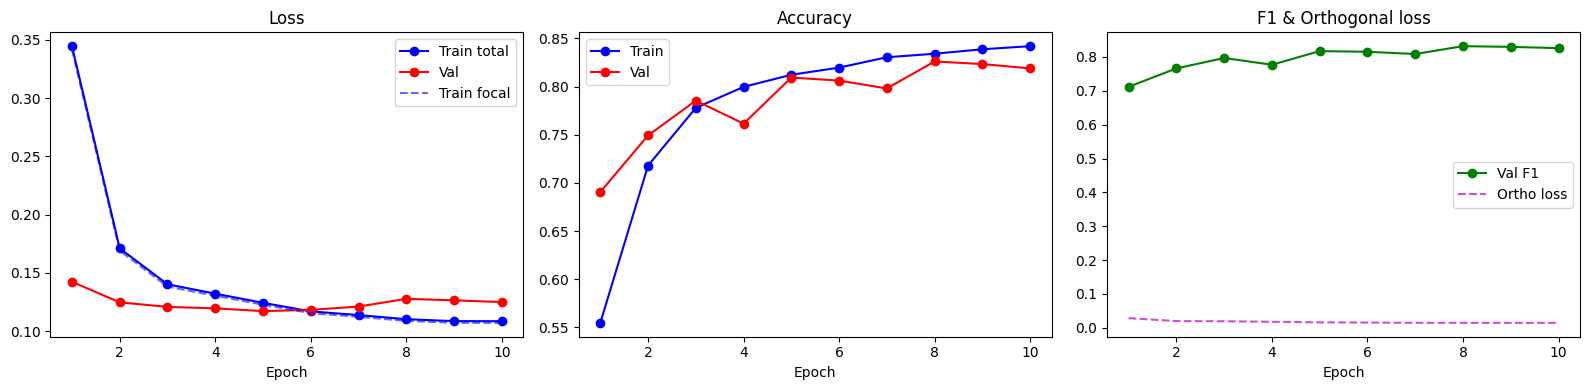

In [14]:
er = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(er, history['train_loss'],  'b-o', label='Train total')
axes[0].plot(er, history['val_loss'],    'r-o', label='Val')
axes[0].plot(er, history['train_focal'], 'b--', label='Train focal', alpha=0.6)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(er, history['train_acc'], 'b-o', label='Train')
axes[1].plot(er, history['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(er, history['val_f1'],       'g-o', label='Val F1')
axes[2].plot(er, history['train_ortho'],  'm--', label='Ortho loss', alpha=0.7)
axes[2].set_title('F1 & Orthogonal loss'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v3.png', dpi=150)
plt.show()

## 12. Threshold tuning on validation set

Best threshold : 0.62
Val F1 at best : 0.8495
Val Acc at best: 0.8546


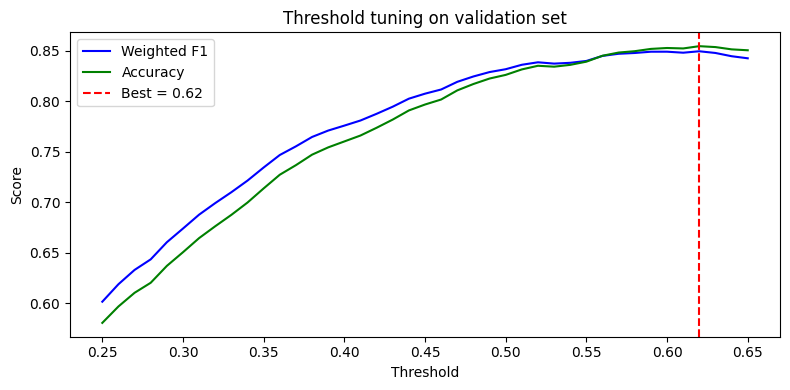

In [15]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

_, _, _, _, val_labels_arr, val_probs_arr = evaluate(
    model, val_dl, criterion, DEVICE, threshold=0.5)

thresholds = np.arange(0.25, 0.66, 0.01)
f1_scores, acc_scores = [], []

for t in thresholds:
    preds = (val_probs_arr >= t).astype(int)
    f1_scores.append(f1_score(val_labels_arr, preds, average='weighted'))
    acc_scores.append(accuracy_score(val_labels_arr, preds))

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]

print(f'Best threshold : {BEST_THRESHOLD:.2f}')
print(f'Val F1 at best : {f1_scores[best_idx]:.4f}')
print(f'Val Acc at best: {acc_scores[best_idx]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores,  'b-', label='Weighted F1')
plt.plot(thresholds, acc_scores, 'g-', label='Accuracy')
plt.axvline(BEST_THRESHOLD, color='red', linestyle='--',
            label=f'Best = {BEST_THRESHOLD:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold tuning on validation set')
plt.legend(); plt.tight_layout()
plt.savefig('/kaggle/working/threshold_curve_v3.png', dpi=150)
plt.show()

## 13. Final test evaluation

In [16]:
_, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_dl, criterion, DEVICE, threshold=BEST_THRESHOLD)

print('=' * 55)
print(f'Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test F1        : {test_f1:.4f}')
print(f'Threshold used : {BEST_THRESHOLD:.2f}')
print('=' * 55)
print()
print(classification_report(test_labels, test_preds, target_names=['Real', 'Fake']))

Test Accuracy  : 0.8500  (85.00%)
Test F1        : 0.8476
Threshold used : 0.62

              precision    recall  f1-score   support

        Real       0.89      0.92      0.90      1682
        Fake       0.71      0.64      0.67       532

    accuracy                           0.85      2214
   macro avg       0.80      0.78      0.79      2214
weighted avg       0.85      0.85      0.85      2214



## 14. Confusion matrix

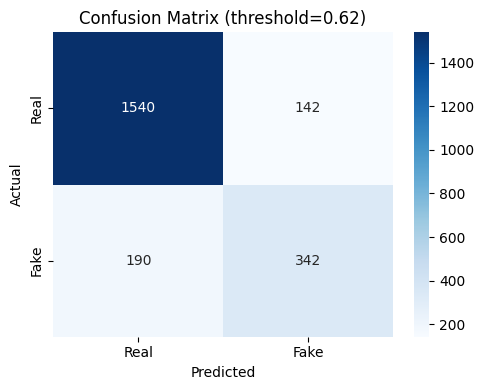

True  Real (TN) : 1540
False Fake (FP) : 142  ← real wrongly called fake
False Real (FN) : 190  ← fake news missed
True  Fake (TP) : 342
Fake Recall     : 0.6429
Fake Precision  : 0.7066


In [17]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix (threshold={BEST_THRESHOLD:.2f})')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_v3.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Real (TN) : {tn}')
print(f'False Fake (FP) : {fp}  ← real wrongly called fake')
print(f'False Real (FN) : {fn}  ← fake news missed')
print(f'True  Fake (TP) : {tp}')
print(f'Fake Recall     : {tp/(tp+fn):.4f}')
print(f'Fake Precision  : {tp/(tp+fp):.4f}')

## 15. Gate & orthogonality analysis

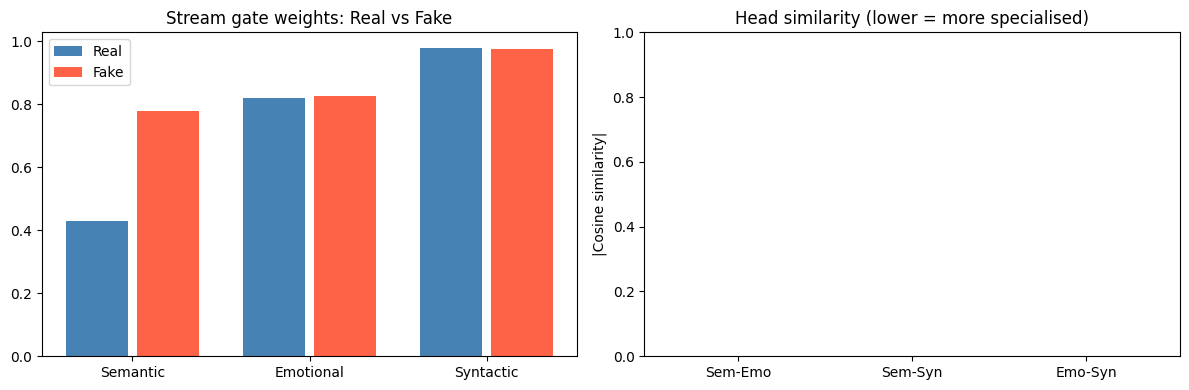


Gate values:
  Semantic      real=0.428  fake=0.777
  Emotional     real=0.821  fake=0.827
  Syntactic     real=0.979  fake=0.974

Head cosine similarities (closer to 0 = better specialisation):
  Sem-Emo: 0.0023
  Sem-Syn: 0.0010
  Emo-Syn: 0.0006


In [18]:
@torch.no_grad()
def collect_all(model, loader, device):
    model.eval()
    all_gates, all_sem, all_emo, all_syn, all_labels = [], [], [], [], []
    for batch in loader:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        ttype = batch['token_type_ids'].to(device)
        _, gates, sem, emo, syn = model(ids, mask, ttype)
        all_gates.append(gates.cpu().numpy())
        all_sem.append(F.normalize(sem, dim=-1).cpu().numpy())
        all_emo.append(F.normalize(emo, dim=-1).cpu().numpy())
        all_syn.append(F.normalize(syn, dim=-1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())
    return (np.vstack(all_gates), np.vstack(all_sem),
            np.vstack(all_emo),   np.vstack(all_syn), np.array(all_labels))

gates_arr, sem_arr, emo_arr, syn_arr, gate_labels = collect_all(model, test_dl, DEVICE)

# Gate weights
stream_names = ['Semantic', 'Emotional', 'Syntactic']
mean_real = gates_arr[gate_labels == 0].mean(axis=0)
mean_fake = gates_arr[gate_labels == 1].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(3)
axes[0].bar(x - 0.2, mean_real, 0.35, label='Real', color='steelblue')
axes[0].bar(x + 0.2, mean_fake, 0.35, label='Fake', color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(stream_names)
axes[0].set_title('Stream gate weights: Real vs Fake')
axes[0].legend()

# Cosine similarity between heads (lower = more specialised)
sim_se = (sem_arr * emo_arr).sum(-1).mean()
sim_sn = (sem_arr * syn_arr).sum(-1).mean()
sim_en = (emo_arr * syn_arr).sum(-1).mean()
sims   = [abs(sim_se), abs(sim_sn), abs(sim_en)]
pairs  = ['Sem-Emo', 'Sem-Syn', 'Emo-Syn']
axes[1].bar(pairs, sims, color=['#4472C4', '#ED7D31', '#A9D18E'])
axes[1].set_title('Head similarity (lower = more specialised)')
axes[1].set_ylabel('|Cosine similarity|')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/kaggle/working/gate_analysis_v3.png', dpi=150)
plt.show()

print('\nGate values:')
for i, name in enumerate(stream_names):
    print(f'  {name:12s}  real={mean_real[i]:.3f}  fake={mean_fake[i]:.3f}')
print('\nHead cosine similarities (closer to 0 = better specialisation):')
for p, s in zip(pairs, sims):
    print(f'  {p}: {s:.4f}')

## 16. Inference on custom titles

In [19]:
@torch.no_grad()
def predict(titles, model, tokenizer, device, max_len=64, threshold=0.35):
    model.eval()
    enc = tokenizer(
        titles, max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    ids   = enc['input_ids'].to(device)
    mask  = enc['attention_mask'].to(device)
    ttype = enc.get('token_type_ids', torch.zeros_like(ids)).to(device)

    logits, gates, _, _, _ = model(ids, mask, ttype)
    probs      = torch.softmax(logits, dim=-1).cpu().numpy()
    fake_probs = probs[:, 1]
    preds      = (fake_probs >= threshold).astype(int)

    print(f'Threshold: {threshold:.2f}\n')
    for title, pred, fp in zip(titles, preds, fake_probs):
        label = 'FAKE' if pred == 1 else 'REAL'
        conf  = fp if pred == 1 else 1 - fp
        print(f'[{label}] {conf*100:.1f}%  →  "{title}"')


sample_titles = [
    "Taylor Swift surprises fans with secret album drop",
    "SHOCKING: Celebrity fakes death to avoid taxes — proof inside!",
    "Beyoncé announces world tour dates for 2025",
    "You won't BELIEVE what this actress did at the Oscars",
    "Actor spotted leaving hospital after secret surgery",
]

predict(sample_titles, model, tokenizer, DEVICE, threshold=BEST_THRESHOLD)

Threshold: 0.62

[REAL] 63.3%  →  "Taylor Swift surprises fans with secret album drop"
[FAKE] 86.3%  →  "SHOCKING: Celebrity fakes death to avoid taxes — proof inside!"
[REAL] 80.4%  →  "Beyoncé announces world tour dates for 2025"
[REAL] 79.8%  →  "You won't BELIEVE what this actress did at the Oscars"
[REAL] 66.0%  →  "Actor spotted leaving hospital after secret surgery"


## 17. Output summary

In [20]:
files = [
    'titan_fnd_v3_best.pt',
    'training_curves_v3.png',
    'threshold_curve_v3.png',
    'confusion_matrix_v3.png',
    'gate_analysis_v3.png',
]
print('Outputs in /kaggle/working/\n')
for f in files:
    path   = f'/kaggle/working/{f}'
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    print(f'  {"OK" if exists else "MISSING":6s}  {f}  ({size/1024:.1f} KB)')

print(f'\n{"="*55}')
print(f'Final Test Accuracy : {test_acc*100:.2f}%')
print(f'Final Test F1       : {test_f1:.4f}')
print(f'Optimal Threshold   : {BEST_THRESHOLD:.2f}')
print(f'{"="*55}')

Outputs in /kaggle/working/

  OK      titan_fnd_v3_best.pt  (724264.9 KB)
  OK      training_curves_v3.png  (93.3 KB)
  OK      threshold_curve_v3.png  (57.9 KB)
  OK      confusion_matrix_v3.png  (33.4 KB)
  OK      gate_analysis_v3.png  (43.4 KB)

Final Test Accuracy : 85.00%
Final Test F1       : 0.8476
Optimal Threshold   : 0.62
